In [ ]:
!pip install opencv-python

## Import knižníc

Táto bunka načítava všetky potrebné knižnice pre spracovanie dát, trénovanie modelu a vizualizáciu výsledkov.

In [ ]:
import os
import glob
import cv2
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import random
from tensorflow.keras.models import load_model
import json

## Konfigurácia, načítanie datasetov a príprava dát

Táto bunka definuje základné parametre trénovania, načítava všetky dostupné datasety, vykonáva párovanie obrázkov s maskami, predspracovanie, spájanie datasetov a následné rozdelenie na trénovaciu, validačnú a testovaciu množinu. Okrem toho ukladá testovaciu množinu do samostatného adresára pre neskoršie vyhodnocovanie.

### Konfigurácia trénovania
- `IMG_SIZE` – cieľová veľkosť obrázkov pre model (384×384 px).
- `BATCH_SIZE` – počet vzoriek v jednej dávke.
- `EPOCHS` – počet trénovacích epoch.
- `datasets` – zoznam všetkých zásielok s cestami k obrázkom a ručným maskám.

### Funkcia `load_image_mask()`
Zabezpečuje načítanie a predspracovanie jedného obrázka a jeho masky:
- načítanie obrázka cez OpenCV,
- konverzia do RGB,
- zmena veľkosti na `IMG_SIZE`,
- normalizácia pixelov do rozsahu 0–1,
- načítanie masky v odtieňoch šedej,
- binarizácia masky (threshold > 128),
- rozšírenie dimenzie masky na tvar `(H, W, 1)`.

### Funkcia `load_dataset()`
Načítava celý dataset z dvoch priečinkov (obrázky + masky):
- filtruje súbory podľa prípon,
- čistí názvy súborov, aby sa dali správne spárovať,
- vytvára mapovanie `meno → cesta`,
- spáruje obrázky s maskami podľa názvu,
- načíta všetky dvojice pomocou `load_image_mask()`,
- vracia:
  - `images` – numpy pole obrázkov,
  - `masks` – numpy pole masiek,
  - `img_paths` – pôvodné cesty k obrázkom,
  - `mask_paths` – pôvodné cesty k maskám.
### Načítanie všetkých datasetov
Pre každú zásielku:
- načíta obrázky a masky,
- vypíše počet spárovaných položiek,
- pridá ich do spoločných zoznamov.

Následne sa všetky datasety spoja do jedného veľkého datasetu:
- `X_all` – všetky obrázky,
- `y_all` – všetky masky,
- `img_paths_all`, `mask_paths_all` – cesty k pôvodným súborom.

### Rozdelenie datasetu
Dataset sa rozdelí v dvoch krokoch:
1. **Train / Temp** (85 % / 15 %)
2. **Val / Test** (z Temp: 50 % / 50 %)

Výsledné množiny:
- `X_train`, `y_train`
- `X_val`, `y_val`
- `X_test`, `y_test`

Súčasne sa rozdeľujú aj cesty k obrázkom a maskám.

### Uloženie testovacej množiny
Testovacia množina sa uloží do zvoleného adresára


In [ ]:
IMG_SIZE = (384, 384)
BATCH_SIZE = 8
EPOCHS = 200

datasets = [
    ("Zásielka 1", Path("../data/CropPictures/orezane_zasielka1_new"), Path("../data/RucneMasky/zasielka1")),
    ("Zásielka 2", Path("../data/CropPictures/orezane_zasielka2_new"), Path("../data/RucneMasky/zasielka2")),
    ("Zásielka 3", Path("../data/CropPictures/orezane_zasielka3_new"), Path("../data/RucneMasky/zasielka3")),
    ("Zásielka 4", Path("../data/CropPictures/orezane_zasielka4_new"), Path("../data/RucneMasky/zasielka4")),
    ("Zásielka 5", Path("../data/CropPictures/orezane_zasielka5_new"), Path("../data/RucneMasky/zasielka5")),
    ("Zásielka 6", Path("../data/CropPictures/orezane_zasielka6_new"), Path("../data/RucneMasky/zasielka6")),
    ("Zásielka 7", Path("../data/CropPictures/orezane_zasielka7_new"), Path("../data/RucneMasky/zasielka7")),
    ("Zásielka 8", Path("../data/CropPictures/orezane_zasielka8_new"), Path("../data/RucneMasky/zasielka8")),
    ("Zásielka 9", Path("../data/CropPictures/orezane_zasielka9_new"), Path("../data/RucneMasky/zasielka9")),
    ("Zásielka 10", Path("../data/CropPictures/orezane_zasielka10_new"), Path("../data/RucneMasky/zasielka10")),
    ("Zásielka 11", Path("../data/CropPictures/orezane_zasielka11_new"), Path("../data/RucneMasky/zasielka11")),
    ("Zásielka 12", Path("../data/CropPictures/orezane_zasielka12_new"), Path("../data/RucneMasky/zasielka12")),
    ("Zásielka 13", Path("../data/CropPictures/orezane_zasielka13_new"), Path("../data/RucneMasky/zasielka13")),
]

def load_image_mask(image_path, mask_path, img_size=IMG_SIZE):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, img_size, interpolation=cv2.INTER_CUBIC)
    image = image / 255.0

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, img_size, interpolation=cv2.INTER_NEAREST)
    mask = (mask > 128).astype(np.uint8)
    mask = np.expand_dims(mask, axis=-1)

    return image, mask


def load_dataset(image_folder: Path, mask_folder: Path):
    exts_img = [".jpg", ".jpeg", ".png"]
    exts_mask = [".png", ".jpg"]

    def clean_name(path: Path):
        name = path.stem.strip()
        while name.startswith(("!", "s", "S")):
            name = name[1:]
        for suffix in ["_mask", "_maska", "_seg", "-mask"]:
            name = name.replace(suffix, "")
        return name

    image_files = {clean_name(p): p for ext in exts_img for p in image_folder.glob(f"*{ext}") if p.is_file()}
    mask_files  = {clean_name(p): p for ext in exts_mask for p in mask_folder.glob(f"*{ext}") if p.is_file()}

    keys = sorted(set(image_files.keys()) & set(mask_files.keys()))
    print(f"Spárovaných: {len(keys)} obrázkov")

    images, masks, img_paths, mask_paths = [], [], [], []

    for k in keys:
        img, mask = load_image_mask(image_files[k], mask_files[k])
        images.append(img)
        masks.append(mask)
        img_paths.append(image_files[k])
        mask_paths.append(mask_files[k])

    return (
        np.array(images, np.float32),
        np.array(masks, np.uint8),
        np.array(img_paths),
        np.array(mask_paths),
    )

# NAČÍTANIE DÁT
all_images = []
all_masks = []
all_img_paths = []
all_mask_paths = []

print("\n=== Načítavanie datasetov ===")
for name, img_path, mask_path in datasets:
    print(f"\n{name}:")
    Xtmp, ytmp, iptmp, mptmp = load_dataset(img_path, mask_path)
    print(f"Načítaných dokopy: {Xtmp.shape[0]}")

    all_images.append(Xtmp)
    all_masks.append(ytmp)
    all_img_paths.append(iptmp)
    all_mask_paths.append(mptmp)

X_all = np.concatenate(all_images, axis=0)
y_all = np.concatenate(all_masks, axis=0)
img_paths_all = np.concatenate(all_img_paths, axis=0)
mask_paths_all = np.concatenate(all_mask_paths, axis=0)

print(f"\nSpolu všetkých obrázkov: {X_all.shape[0]}")

# SPLIT
X_train, X_temp, y_train, y_temp, ip_train, ip_temp, mp_train, mp_temp = train_test_split(
    X_all, y_all, img_paths_all, mask_paths_all,
    test_size=0.15,
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test, ip_val, ip_test, mp_val, mp_test = train_test_split(
    X_temp, y_temp, ip_temp, mp_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("\n=== Výsledné rozdelenie ===")
print(f"Train: {X_train.shape[0]}")
print(f"Val:   {X_val.shape[0]}")
print(f"Test:  {X_test.shape[0]}")

# ULOŽENIE TEST SETU
test_root = Path("test10_12DeepLabV3")
test_img_dir = test_root / "images"
test_mask_dir = test_root / "masks"

test_img_dir.mkdir(parents=True, exist_ok=True)
test_mask_dir.mkdir(parents=True, exist_ok=True)

for img_path, mask_path in zip(ip_test, mp_test):
    img = cv2.imread(str(img_path))
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    cv2.imwrite(str(test_img_dir / img_path.name), img)
    cv2.imwrite(str(test_mask_dir / mask_path.name), mask)

print(f"\nTestovacia množina uložená do: {test_root}")


## Rozšírenie (dilatácia) masiek pre tréning a vizuálna kontrola

V tejto bunke sa vykonáva **dilatácia masiek**, čo je morfologická operácia používaná na mierne zväčšenie objektov v binárnej maske. Tento krok sa aplikuje **iba na trénovaciu množinu**.

### `dilate_masks()`
- Vytvorí štruktúrny prvok (kernel) o veľkosti `kernel_size × kernel_size`.
- Pre každú masku vykoná jednu iteráciu dilatácie pomocou `cv2.dilate()`.
- Výsledkom je maska so „zhrubnutými“ hranami objektov.

### Vizuálna kontrola
Bunka zobrazuje porovnanie:
- **Pôvodnej masky**  
- **Dilatovanej masky** 

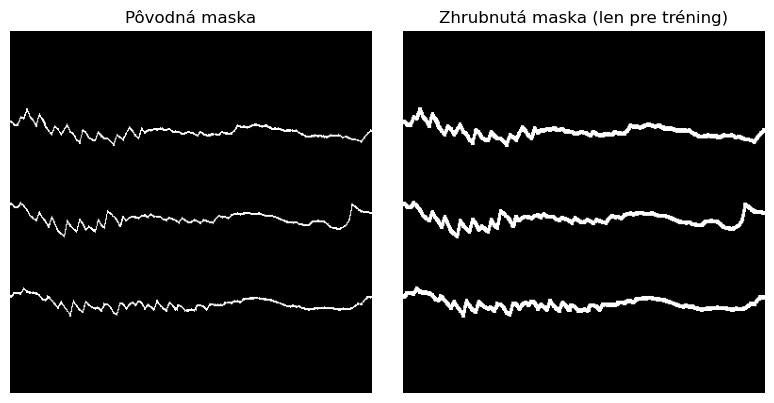

In [4]:
# DILATÁCIA (len pre tréning) 
def dilate_masks(masks, kernel_size=3):
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    dilated = []
    for m in masks:
        m_dil = cv2.dilate(m, kernel, iterations=1)
        dilated.append(m_dil)
    return np.array(dilated, dtype=np.uint8)
y_train_dilated = dilate_masks(y_train, kernel_size=3)


# vizuálna kontrola dilatácie
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(np.squeeze(y_train[0]), cmap="gray")
plt.title("Pôvodná maska")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.squeeze(y_train_dilated[0]), cmap="gray")
plt.title("Zhrubnutá maska (len pre tréning)")
plt.axis("off")

plt.tight_layout()
plt.show()

## Augmentácia

Táto bunka definuje funkciu **augmentáciu dát**, ktorá generuje viacero variácií jedného obrázka a jeho masky. Cieľom je zvýšiť robustnosť modelu a zlepšiť generalizáciu pri trénovaní.

Funkcia `augment_combined()` vykonáva viacero typov transformácií, pričom zabezpečuje, aby boli **obrázok aj maska transformované konzistentne**.

### Funkcia `augment_combined(image, mask, num_aug=2)`

Funkcia vytvorí `num_aug` augmentovaných verzií vstupného obrázka a masky. Výstupom sú dva zoznamy:
- `aug_images` – pôvodný + augmentované obrázky,
- `aug_masks` – pôvodná + augmentované masky.

### Aplikované augmentácie

#### **Rotácia a posun**  
S pravdepodobnosťou 0.9 sa vykoná:
- rotácia v rozsahu ±5°,
- horizontálny a vertikálny posun (±10 px),

#### **Zmena jasu / gamma korekcia**  
S pravdepodobnosťou 0.9:
- aplikácia gamma transformácie v rozsahu 0.7–1.6,

#### **Gaussov šum**  
S pravdepodobnosťou 0.7:
- pridanie mierneho šumu (σ = 0.03),

#### **Vertikálne dropout pásy**  
S pravdepodobnosťou 0.7:
- náhodné zatemnenie úzkych vertikálnych pásov,

#### **Rozmazanie (Gaussian blur)**  
S pravdepodobnosťou 0.5:
- aplikácia blur filtra s kernelom 3×3 alebo 5×5,

#### **Binarizácia masky**  
Po všetkých transformáciách sa maska opäť binarizuje:
- hodnoty > 0.5 → 1  
- inak → 0  

In [5]:
def augment_combined(image, mask, num_aug=2):
    # zaruč masku ako (H,W,1)
    if mask.ndim == 2:
        mask = np.expand_dims(mask, axis=-1)

    image = image.astype(np.float32)
    if image.max() > 1.5:
        image = image / 255.0

    h, w = IMG_SIZE

    aug_images = [image]
    aug_masks = [mask]

    for _ in range(num_aug):
        img_aug = image.copy()
        mask_aug = mask.copy()

        # Rotácia + posun 
        if random.random() < 0.9:
            angle = random.uniform(-5, 5)
            tx = random.uniform(-10, 10)
            ty = random.uniform(-10, 10)

            M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1)
            M[0, 2] += tx
            M[1, 2] += ty

            img_aug = cv2.warpAffine(
                img_aug,
                M,
                (w, h),
                flags=cv2.INTER_LINEAR,
                borderMode=cv2.BORDER_REFLECT,
            )

            mask_aug = cv2.warpAffine(
                mask_aug[..., 0],
                M,
                (w, h),
                flags=cv2.INTER_NEAREST,
                borderMode=cv2.BORDER_REFLECT,
            )

            mask_aug = np.expand_dims(mask_aug, axis=-1)

        # Jas / gamma 
        if random.random() < 0.9:
            gamma = random.uniform(0.7, 1.6)
            img_aug = np.power(np.clip(img_aug, 0, 1), gamma)

        # Gaussov šum
        if random.random() < 0.7:
            noise = np.random.normal(0, 0.03, img_aug.shape).astype(np.float32)
            img_aug = np.clip(img_aug + noise, 0, 1)

        # Dropout vertikálne pásy 
        if random.random() < 0.7:
            num_stripes = random.randint(1, 5)
            for _ in range(num_stripes):
                x0 = random.randint(0, w - 10)
                stripe_w = random.randint(3, 12)
                img_aug[:, x0:x0 + stripe_w, :] = 0.0

        # Blur
        if random.random() < 0.5:
            k = random.choice([3, 5])
            img_aug = cv2.GaussianBlur(img_aug, (k, k), 0)

        # binarizácia masky
        mask_aug = (mask_aug > 0.5).astype(np.uint8)

        aug_images.append(img_aug)
        aug_masks.append(mask_aug)

    return aug_images, aug_masks


## Spustenie kombinovanej augmentácie nad trénovacou množinou

V tejto bunke sa vykonáva hromadná augmentácia všetkých obrázkov v trénovacej množine. Pre každý obrázok a jeho dilatovanú masku sa vygenerujú viaceré nové varianty pomocou funkcie `augment_combined()`.

### Priebeh augmentácie
- Pre každý obrázok v `X_train` a jeho masku v `y_train_dilated` sa zavolá:

Funkcia `augment_combined` vráti:
- pôvodný obrázok + 3 augmentované verzie,
- pôvodnú masku + 3 augmentované verzie.
- Všetky výsledky sa postupne ukladajú do zoznamov `augmented_images` a `augmented_masks`.

### Výsledná trénovacia množina
Po ukončení augmentácie sa zoznamy skonvertujú na numpy polia:
- `X_train_final` – finálna množina obrázkov pre tréning,
- `y_train_final` – finálna množina masiek.



In [ ]:
print("Prebieha augmentácia")

augmented_images = []
augmented_masks = []

for img, mask in zip(X_train, y_train_dilated):
    ai, am = augment_combined(img, mask, num_aug=3) 
    augmented_images.extend(ai)
    augmented_masks.extend(am)

X_train_final = np.array(augmented_images, dtype=np.float32)
y_train_final = np.array(augmented_masks, dtype=np.uint8)

print(f"Tréningová sada po augmentácii: {len(X_train_final)} (pôvodne {len(X_train)})")


## Vizualizácia augmentovaného obrázka a masky

Táto bunka slúži na rýchlu vizuálnu kontrolu kvality augmentácie. Zobrazuje jeden náhodne vybraný pár z finálnej trénovacej množiny (`X_train_final`, `y_train_final`)

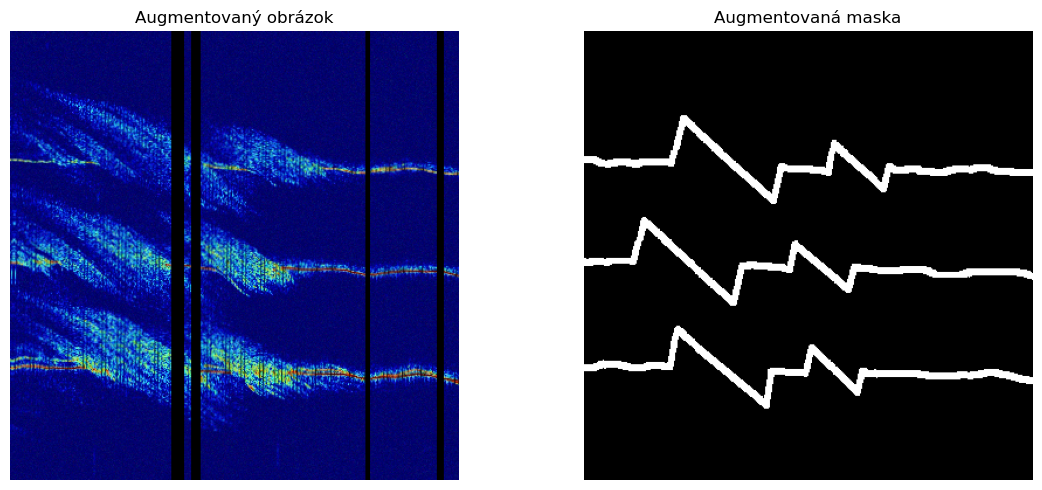

In [7]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(X_train_final[38])
plt.title("Augmentovaný obrázok")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(y_train_final[38][..., 0], cmap="gray")
plt.title("Augmentovaná maska")
plt.axis("off")
plt.tight_layout()
plt.show()


In [8]:
print("Shape obrázka:", X_train_final.shape)
print("Shape masky:", y_train_final.shape)

Shape obrázka: (3344, 384, 384, 3)
Shape masky: (3344, 384, 384, 1)


## Príprava TensorFlow datasetov pre tréning a validáciu

Táto bunka vytvára efektívne dátové pipeline pomocou `tf.data.Dataset`.

### Tréningový dataset (`train_dataset`)
Dataset je vytvorený zo vstupných numpy polí `X_train_final` a `y_train_final`, ktoré už obsahujú:
- pôvodné trénovacie dáta,
- dilatované masky,
- všetky augmentované verzie.

Použité operácie:
- **`shuffle()`** – premieša dáta pri každej epoche, čím zlepšuje generalizáciu modelu.
- **`batch(BATCH_SIZE)`** – rozdelí dáta do dávok o veľkosti `BATCH_SIZE`.
- **`prefetch(tf.data.AUTOTUNE)`** – umožní paralelné načítavanie ďalšej dávky počas trénovania, čím zrýchľuje pipeline.

### Validačný dataset (`val_dataset`)
Validačné dáta sa neaugmentujú ani nemiešajú:
- zachováva sa konzistentnosť pri hodnotení modelu,
- používa sa len batching a prefetching.

Tieto datasety sú pripravené na priame použitie v `model.fit()`.


In [9]:
# ---------------- DATASET ----------------
train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train_final, y_train_final))
      .shuffle(len(X_train_final))
      .batch(BATCH_SIZE)
      .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
      .batch(BATCH_SIZE)
      .prefetch(tf.data.AUTOTUNE)
)

2026-04-03 06:45:06.178411: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 5917114368 exceeds 10% of free system memory.


## Definícia modelu DeepLabV3 s ResNet50 backbone

Táto bunka implementuje architektúru **DeepLabV3**. Ako základ (backbone) používa **ResNet50**, tentokrát bez predtrénovaných váh (`weights=None`), pričom vrchné klasifikačné vrstvy sú odstránené (`include_top=False`).

Výstupom je segmentačná mapa s jedným kanálom (binárna segmentácia) a aktiváciou `sigmoid`.

### Hlavné komponenty modelu

#### **Backbone – ResNet50**
- `weights=None` znamená, že sieť sa inicializuje náhodne.
- Používa sa ako extraktor hlbokých príznakov.
- Dve dôležité vrstvy:
  - `conv4_block6_out` – hlboké príznaky pre ASPP,
  - `conv2_block3_out` – nízkoúrovňové detaily pre skip connection.

### ASPP (Atrous Spatial Pyramid Pooling)

Funkcia `ASPP(x)` vytvára viacero paralelných vetiev s rôznymi dilatačnými koeficientmi:

- 1×1 konvolúcia (bez dilácie),
- 3×3 konvolúcie s diláciou 6, 12 a 18,
- globálny priemerovací pooling + upsampling.

Tieto vetvy sa následne:
- skombinujú pomocou `Concatenate`,
- preženú 1×1 konvolúciou,
- regularizujú dropoutom.

### Spojenie s nízkoúrovňovými príznakmi

- Z vrstvy `conv2_block3_out` sa extrahujú detaily s vysokým rozlíšením.
- Prechádzajú 1×1 konvolúciou (zníženie počtu kanálov na 48).
- Spoja sa s upsamplovaným výstupom ASPP.

### Upsampling a finálne vrstvy

- Dve 3×3 konvolúcie s regularizáciou L2.
- Dropout pre regularizáciu.
- Finálny upsampling ×4 na pôvodné rozlíšenie.
- Výstupná 1×1 konvolúcia s `sigmoid` aktiváciou → binárna maska.

### Výstup funkcie
Funkcia `build_deeplabv3()` vracia plne zostavený model typu `tf.keras.Model`, pripravený na kompiláciu a trénovanie.




In [10]:
def build_deeplabv3(input_shape=(384, 384, 3), num_classes=1):
    reg = tf.keras.regularizers.l2(1e-5)

    base_model = tf.keras.applications.ResNet50(
        weights=None, include_top=False, input_shape=input_shape
    )


    def ASPP(x):
        h, w = x.shape[1], x.shape[2]

        y1 = tf.keras.layers.Conv2D(256, 1, padding="same", activation="relu", kernel_regularizer=reg)(x)
        y2 = tf.keras.layers.Conv2D(256, 3, dilation_rate=6, padding="same", activation="relu", kernel_regularizer=reg)(x)
        y3 = tf.keras.layers.Conv2D(256, 3, dilation_rate=12, padding="same", activation="relu", kernel_regularizer=reg)(x)
        y4 = tf.keras.layers.Conv2D(256, 3, dilation_rate=18, padding="same", activation="relu", kernel_regularizer=reg)(x)

        y5 = tf.keras.layers.GlobalAveragePooling2D()(x)
        y5 = tf.keras.layers.Reshape((1, 1, y5.shape[-1]))(y5)
        y5 = tf.keras.layers.Conv2D(256, 1, padding="same", activation="relu", kernel_regularizer=reg)(y5)
        y5 = tf.keras.layers.UpSampling2D(size=(h, w), interpolation="bilinear")(y5)

        y = tf.keras.layers.Concatenate()([y1, y2, y3, y4, y5])
        y = tf.keras.layers.Conv2D(256, 1, padding="same", activation="relu", kernel_regularizer=reg)(y)

        y = tf.keras.layers.Dropout(0.1)(y)
        return y

    x = base_model.get_layer("conv4_block6_out").output
    x = ASPP(x)
    x = tf.keras.layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x)

    low_level = base_model.get_layer("conv2_block3_out").output
    low_level = tf.keras.layers.Conv2D(48, 1, padding="same", activation="relu")(low_level)

    x = tf.keras.layers.Concatenate()([x, low_level])

    x = tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu", kernel_regularizer=reg)(x)
    x = tf.keras.layers.Dropout(0.1)(x)
    x = tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu", kernel_regularizer=reg)(x)

    x = tf.keras.layers.UpSampling2D(size=(4, 4), interpolation="bilinear")(x)
    outputs = tf.keras.layers.Conv2D(num_classes, 1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=outputs)
    return model


## Metriky a stratové funkcie

Táto bunka definuje metriky a stratové funkcie používané pri trénovaní segmentačného modelu:

- **Dice score** 
- **IoU score** 
- **Tversky index** 
- **Tversky loss** 
- **BCE + Dice loss**
- **Focal Tversky loss**

Všetky funkcie pracujú s binárnou segmentáciou a sú pripravené na použitie pri kompilácii modelu.


In [11]:
def dice_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)  
    y_pred = tf.cast(y_pred, tf.float32)
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def iou_score(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    union = tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) - intersection

    return (intersection + smooth) / (union + smooth)

def tversky_index(y_true, y_pred, alpha=0.3, beta=0.7, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    TP = tf.keras.backend.sum(y_true_f * y_pred_f)
    FP = tf.keras.backend.sum((1 - y_true_f) * y_pred_f)
    FN = tf.keras.backend.sum(y_true_f * (1 - y_pred_f))

    return (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)

def tversky_loss(y_true, y_pred):
    return 1 - tversky_index(y_true, y_pred)



def bce_dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)  
    y_pred = tf.cast(y_pred, tf.float32)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = 1 - dice_score(y_true, y_pred)
    return bce + dice

def focal_tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7, gamma=0.75, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    TP = tf.keras.backend.sum(y_true_f * y_pred_f)
    FP = tf.keras.backend.sum((1 - y_true_f) * y_pred_f)
    FN = tf.keras.backend.sum(y_true_f * (1 - y_pred_f))

    tversky = (TP + smooth) / (TP + alpha * FP + beta * FN + smooth)
    return tf.pow((1 - tversky), gamma)



## Callbacky pre vizualizáciu, checkpointy a ukladanie histórie

Táto bunka definuje viacero callbackov používaných počas tréningu:

- **ShowPredictionCallback**  
  Po každej epoche (alebo v danom intervale) zobrazí vstupný obrázok, skutočnú masku a aktuálnu predikciu modelu.

- **EpochCheckpoint**  
  Ukladá checkpoint modelu po každej epoche pomocou `ckpt_manager`.

- **HistorySaver**  
  Priebežne ukladá trénovacie metriky do JSON súboru, aby sa dali neskôr analyzovať alebo obnoviť.

- **SaveBestModelCallback**  
  Sleduje vybranú validačnú metriku (napr. `val_dice_score`) a uloží model vždy, keď dosiahne nový najlepší výsledok.



In [12]:
# ---------------- CALLBACKY ----------------
class ShowPredictionCallback(tf.keras.callbacks.Callback):
    def __init__(self, model_ref, test_image, test_mask, epoch_interval=1):
        super().__init__()
        self._model_ref = model_ref
        self.test_image = np.expand_dims(test_image, axis=0)
        self.test_mask = test_mask
        self.epoch_interval = epoch_interval

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.epoch_interval == 0:
            pred = self._model_ref.predict(self.test_image)[0, ..., 0]
            pred_bin = (pred > 0.5).astype(np.float32)
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(self.test_image[0])
            axes[0].set_title("Vstupný obrázok")
            axes[1].imshow(self.test_mask[..., 0], cmap="gray")
            axes[1].set_title("Skutočná maska")
            axes[2].imshow(pred_bin, cmap="gray")
            axes[2].set_title(f"Predikcia (epocha {epoch+1})")
            for ax in axes: ax.axis("off")
            plt.tight_layout()
            plt.show()

class EpochCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, ckpt_manager):
        super().__init__()
        self.ckpt_manager = ckpt_manager
    def on_epoch_end(self, epoch, logs=None):
        path = self.ckpt_manager.save()
        print(f"\n [Checkpoint Saved] Epoch {epoch+1}: {path}")
        
class HistorySaver(tf.keras.callbacks.Callback):
    def __init__(self, filename="10_12training_history.json"):
        super().__init__()
        self.filename = filename
        self.history = {}

        if os.path.exists(filename):
            with open(filename, "r") as f:
                self.history = json.load(f)

    def on_epoch_end(self, epoch, logs=None):
        for key, value in logs.items():
            self.history.setdefault(key, []).append(float(value))

        with open(self.filename, "w") as f:
            json.dump(self.history, f)


class SaveBestModelCallback(tf.keras.callbacks.Callback):
    def __init__(self, filepath="10_12best_deeplab_model.keras", score_file="10_12best_score.json", monitor="val_dice_score", mode="max"):
        super().__init__()
        self.filepath = filepath
        self.score_file = score_file
        self.monitor = monitor
        self.mode = mode

        # Načítanie predchádzajúcej hodnoty
        if os.path.exists(score_file):
            with open(score_file, "r") as f:
                data = json.load(f)
                self.best = data.get("best_score", -np.inf)
        else:
            self.best = -np.inf if mode == "max" else np.inf

    def on_epoch_end(self, epoch, logs=None):
        current = logs.get(self.monitor)
        if current is None:
            return

        improved = (current > self.best) if self.mode == "max" else (current < self.best)

        if improved:
            self.best = current
            self.model.save(self.filepath)

            # Uložiť nový best score
            with open(self.score_file, "w") as f:
                json.dump({"best_score": float(self.best)}, f)

            print(f"\n [Best Model Saved] Epoch {epoch+1} — {self.monitor}: {current:.4f}")


## Spustenie tréningu modelu DeepLabV3

Táto bunka inicializuje model, načíta váhy z predchádzajúceho tréningu (ak sú dostupné), nastaví optimalizátor, stratovú funkciu, metriky a pripraví všetky callbacky potrebné pre priebeh tréningu.

### Inicializácia modelu
- Vytvorí sa architektúra DeepLabV3 s ResNet50 backbone (bez predtrénovaných váh).
- Ak existuje model `10_11_3best_deeplab_model.keras`, načítajú sa z neho váhy.
- Optimalizátor: **Adam (1e-5)**.
- Strata: **focal_tversky_loss**.
- Metriky: Dice, IoU, Tversky, Accuracy.

### Checkpointing
- Vytvorí sa priečinok pre checkpointy.
- `CheckpointManager` ukladá model po každej epoche.
- Ak existuje posledný checkpoint, tréning pokračuje od neho.

### Callbacky
- **ShowPredictionCallback** 
- **EpochCheckpoint** 
- **SaveBestModelCallback** 
- **ModelCheckpoint** 
- **EarlyStopping** 
- **HistorySaver** 

### Spustenie tréningu
`model.fit()` trénuje model na `train_dataset`, validuje na `val_dataset` a používa všetky callbacky.



In [ ]:
model = build_deeplabv3(input_shape=(384, 384, 3))

if os.path.exists("models/10_11_3best_deeplab_model.keras"):
    model.load_weights("models/10_11_3best_deeplab_model.keras")
    print("Načítané váhy z 10_11_3best_deeplab_model.keras")
else:
    print("Súbor 10_11_3best_deeplab_model.keras neexistuje – trénujem od začiatku.")
    
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer, loss=focal_tversky_loss, metrics=[dice_score, iou_score, tversky_index, "accuracy"])

CHECKPOINT_DIR = "./10_12checkpoints_deeplab"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
ckpt = tf.train.Checkpoint(model=model)
manager = tf.train.CheckpointManager(ckpt, CHECKPOINT_DIR, max_to_keep=EPOCHS)

show_pred_cb = ShowPredictionCallback(model, X_test[0], y_test[0])
epoch_ckpt_cb = EpochCheckpoint(manager)
best_model_cb = SaveBestModelCallback(filepath="10_12best_deeplab_model.keras", monitor="val_dice_score", mode="max")
last_model_cb = tf.keras.callbacks.ModelCheckpoint(filepath="10_12last_epoch_model.keras",save_best_only=False,save_weights_only=False)


early_cb = tf.keras.callbacks.EarlyStopping(monitor="val_dice_score", patience=10, mode="max", restore_best_weights=True)
history_saver_cb = HistorySaver("10_12training_history.json")

initial_epoch = 0
if manager.latest_checkpoint:
    print(f"Načítavam posledný checkpoint: {manager.latest_checkpoint}")
    ckpt.restore(manager.latest_checkpoint).expect_partial()
    try:
        initial_epoch = int(manager.latest_checkpoint.split("-")[-1])
    except:
        initial_epoch = 0
    print(f"Pokračujem od epochy {initial_epoch + 1}.")
else:
    print("Žiadny checkpoint nenájdený — začínam trénovať od začiatku.")



history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[show_pred_cb, best_model_cb, epoch_ckpt_cb, early_cb, last_model_cb, history_saver_cb],
    verbose=1,
)

## Vizualizácia tréningu

Táto bunka načíta uloženú históriu tréningu zo súboru `10_12training_history.json` a vykreslí dva grafy:

- **Dice score (train vs. val)** – ukazuje, ako sa zlepšovala segmentácia počas tréningu.
- **Loss (train vs. val)** – sleduje priebeh stratovej funkcie a odhaľuje pretrénovanie alebo stagnáciu.



In [ ]:
with open("10_12checkpoints_deeplab/10_12training_history.json", "r") as f:
    hist = json.load(f)

plt.figure(figsize=(10,5))
plt.plot(hist["dice_score"], label="train dice")
plt.plot(hist["val_dice_score"], label="val dice")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(hist["loss"], label="train loss")
plt.plot(hist["val_loss"], label="val loss")
plt.legend()
plt.show()


In [16]:
model10_12 = load_model("models/10_12best_deeplab_model.keras", compile=False)

## Funkcia na porovnanie modelov (vizualizácia predikcií)

Táto bunka definuje funkciu `compare_models()`, ktorá umožňuje vizuálne porovnať:

- **jeden model** (predikcia vs. GT), alebo  
- **dva modely** (Model 1 vs. Model 2 vs. GT).

### Čo funkcia robí:
- Vypočíta predikcie pre prvých `num_images` testovacích obrázkov.
- Binarizuje predikcie podľa prahu `threshold`.
- Vytvorí **overlay** (priehľadné prekrytie masky na obrázku).
- Vykreslí mriežku obrázkov:
  - vstupný obrázok,
  - GT masku,
  - predikciu modelu,
  - overlay,
  - voliteľne aj druhý model + jeho overlay.

### Parametre:
- `model1`, `model2` – porovnávané modely (model2 je voliteľný),
- `X_test`, `y_test` – testovacie dáta,
- `num_images` – počet obrázkov na zobrazenie,
- `threshold` – prah pre binarizáciu,
- `alpha` – priehľadnosť overlay masky.



In [17]:
def compare_models(model1, model2=None, X_test=None, y_test=None,num_images=10, threshold=0.5, alpha=0.4):

    preds1 = model1.predict(X_test[:num_images])
    preds1_bin = (preds1 > threshold).astype(np.float32)

    if model2 is not None:
        preds2 = model2.predict(X_test[:num_images])
        preds2_bin = (preds2 > threshold).astype(np.float32)
        two_models = True
    else:
        two_models = False

    cols = 4 if not two_models else 6

    plt.figure(figsize=(4.5 * cols, num_images * 5))

    for i in range(num_images):

        img = X_test[i]
        true_mask = y_test[i].squeeze()

        pred1 = preds1_bin[i].squeeze()

        overlay1 = img.copy()
        mask1 = np.zeros_like(img)
        mask1[..., 0] = pred1
        overlay1 = np.clip(img * (1 - alpha) + mask1 * alpha, 0, 1)

        if two_models:
            pred2 = preds2_bin[i].squeeze()
            overlay2 = img.copy()
            mask2 = np.zeros_like(img)
            mask2[..., 0] = pred2
            overlay2 = np.clip(img * (1 - alpha) + mask2 * alpha, 0, 1)

        plt.subplot(num_images, cols, i * cols + 1)
        plt.imshow(img)
        plt.title("Vstup")
        plt.axis("off")

        plt.subplot(num_images, cols, i * cols + 2)
        plt.imshow(true_mask, cmap="gray")
        plt.title("GT maska")
        plt.axis("off")

        plt.subplot(num_images, cols, i * cols + 3)
        plt.imshow(pred1, cmap="gray")
        plt.title("Model 1 maska")
        plt.axis("off")

        plt.subplot(num_images, cols, i * cols + 4)
        plt.imshow(overlay1)
        plt.title("Overlay M1")
        plt.axis("off")

        if two_models:
            plt.subplot(num_images, cols, i * cols + 5)
            plt.imshow(pred2, cmap="gray")
            plt.title("Model 2 maska")
            plt.axis("off")

            plt.subplot(num_images, cols, i * cols + 6)
            plt.imshow(overlay2)
            plt.title("Overlay M2")
            plt.axis("off")

    plt.tight_layout()
    plt.show()


## Vyhodnotenie modelu na testovacej množine

Funkcia `evaluate_model()` vypočíta priemerné metriky segmentácie na testovacích dátach:

- **Dice score**
- **IoU score**
- **Tversky index**
- **BCE + Dice loss**


Výstupom je prehľadná štatistika kvantitatívnej kvality modelu na testovacej množine.


In [18]:
def evaluate_model(model, X_test, y_test, threshold=0.5):
    preds = model.predict(X_test)

    preds_bin = (preds > threshold).astype(np.float32)

    dice_vals = []
    iou_vals = []
    tversky_vals = []
    loss_vals = []

    for y_true, y_pred, y_raw in zip(y_test, preds_bin, preds):
        # metrics
        d = dice_score(y_true, y_pred).numpy()
        i = iou_score(y_true, y_pred).numpy()
        t = tversky_index(y_true, y_pred).numpy()

        # loss (raw preds)
        l = bce_dice_loss(y_true, y_raw).numpy()

        dice_vals.append(d)
        iou_vals.append(i)
        tversky_vals.append(t)
        loss_vals.append(l)

    return {
        "dice_mean": float(np.mean(dice_vals)),
        "dice_std": float(np.std(dice_vals)),

        "iou_mean": float(np.mean(iou_vals)),
        "iou_std": float(np.std(iou_vals)),

        "tversky_mean": float(np.mean(tversky_vals)),
        "tversky_std": float(np.std(tversky_vals)),

        "loss_mean": float(np.mean(loss_vals)),
        "loss_std": float(np.std(loss_vals))
    }


In [19]:
results_m10_12 = evaluate_model(model10_12, X_test, y_test, threshold=0.4)

print("Model 10_12:")
print(results_m10_12)



2026-04-04 06:21:22.839111: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 4831838208 exceeds 10% of free system memory.


1/3 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step

2026-04-04 06:21:27.949531: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 4831838208 exceeds 10% of free system memory.


3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step
Model 12:
{'dice_mean': 0.5495226979255676, 'dice_std': 0.11938061565160751, 'iou_mean': 0.3874814510345459, 'iou_std': 0.10537303239107132, 'tversky_mean': 0.6276245713233948, 'tversky_std': 0.1370488405227661, 'loss_mean': 1.0494304895401, 'loss_std': 2.9301230907440186}


In [ ]:
compare_models(model10_12, X_test=X_test, y_test=y_test, num_images=74, threshold=0.5)